In [1]:
#Step 1: Load The Dataset
import pandas as pd
df = pd.read_csv("week3_policy_data.csv")
df.head()

,Country,%Renewable,CO2_per_capita,Region,Apply_Policy
0,Nepal,88,1.2,Asia,yes
1,Kenya,65,1.8,Africa,yes
2,Germany,45,6.5,Europe,no
3,India,25,1.9,Asia,yes
4,Australia,35,17.0,Oceania,no


In [2]:
#Step 2: Inspecting datatypes and basic stats
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country         10 non-null     str    
 1   %Renewable      10 non-null     int64  
 2   CO2_per_capita  10 non-null     float64
 3   Region          10 non-null     str    
 4   Apply_Policy    10 non-null     str    
dtypes: float64(1), int64(1), str(3)
memory usage: 532.0 bytes


In [3]:
df.describe()

,%Renewable,CO2_per_capita
count,10.000000,10.000000
mean,48.300000,5.220000
std,31.283826,6.057282
min,12.000000,0.900000
25%,21.250000,1.425000
50%,40.000000,2.000000
75%,76.250000,5.875000
max,95.000000,17.000000


In [4]:
#Step 3: Encode the Target Label
df["Label"] = df["Apply_Policy"].map({"yes": 1, "no": 0})
"""Machine learning models REQUIRE numeric labels, not str. This converts YES and NO to 1 and 0."""

#Veriying if mapping works
df[["Country", "Label"]]

,Country,Label
0,Nepal,1
1,Kenya,1
2,Germany,0
3,India,1
4,Australia,0
5,Brazil,1
6,Nigeria,1
7,Sweden,0
8,Bangladesh,1
9,USA,0


In [14]:
#Step 4: Define Features and Train the Tree
from sklearn.tree import DecisionTreeClassifier
"""Selects input features (X) and output labels (y), and trains a decision tree model with a maximum depth of 3 to avoid
overfitting."""

X = df[["%Renewable", "CO2_per_capita"]]
y = df["Label"]
tree = DecisionTreeClassifier(max_depth=4, random_state=0)
tree.fit(X, y)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current nod

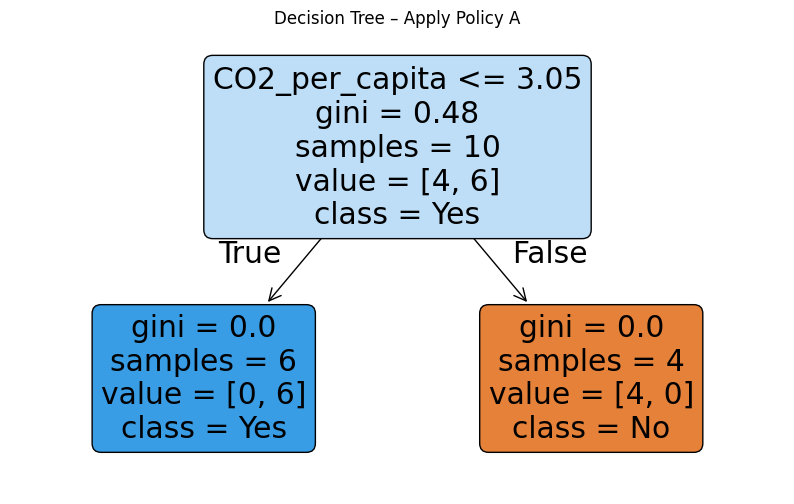

In [15]:
#Step 5 Visualise the Tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plot_tree(tree, feature_names=X.columns, class_names=["No", "Yes"], filled=True, rounded=True)
plt.title("Decision Tree – Apply Policy A")
plt.show()

In [16]:
#Step 6: Make Predictions
new_data = pd.DataFrame({
    "%Renewable": [52, 20, 75],
    "CO2_per_capita": [1.5, 2.5, 3.0]
})
predictions = tree.predict(new_data)
print(predictions)

[1 1 1]
